# [2장 1강] - 실습: 선형 변환의 기하학적 해석

**실습 목표**

- 스케일링·반사·투영·회전 행렬을 데이터에 적용하고 결과를 시각적으로 해석할 수 있다.
- 여러 변환을 합성할 때 행렬 곱 순서에 따라 결과가 달라짐을 확인할 수 있다.
- 선형 변환의 조건(가산성·동차성)을 코드로 검증할 수 있다.
- 평행이동이 포함된 affine 변환이 왜 선형 변환이 아닌지 설명할 수 있다.

**실습에 필요한 데이터셋/파일**

- 분야: 헬스케어
- 데이터셋: UCI Breast Cancer Wisconsin (Diagnostic)
- 사용 방식: `ucimlrepo.fetch_ucirepo(id=17)`
- 출처: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- 사용 목적: 진단 특성 2개를 좌표평면 위의 점으로 보고, 2×2 변환 행렬이 데이터 분포를 어떻게 움직이는지 관찰합니다.
- 준비물: Python, NumPy, pandas, matplotlib, scikit-learn, ucimlrepo

- 선형 변환은 **원점을 기준으로** 작동합니다. 데이터가 원점에서 멀리 떨어져 있으면 회전·반사 결과가 눈에 잘 들어오지 않으므로, 표준화로 평균을 0에 맞춘 뒤 사용합니다.
- 특성 2개만 사용하는 이유는 2차원 좌표평면에 그려서 변환 결과를 눈으로 확인하기 위해서입니다.

In [1]:
# 최초 1회만 실행 (새 환경일 때)
%pip -q install ucimlrepo scikit-learn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def load_uci(dataset_id):
    """UCI에서 데이터를 불러오고, 실패하면 구조가 비슷한 대체 데이터를 사용합니다."""
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=dataset_id)
        X, y = ds.data.features.copy(), ds.data.targets.copy()
        if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
            y = y.iloc[:, 0]
        return X, y
    except Exception as e:
        print('[안내] UCI 로드 실패:', e)
        print('[안내] 대체 데이터(sklearn breast cancer)로 진행합니다.')
        from sklearn.datasets import load_breast_cancer
        data = load_breast_cancer(as_frame=True)
        return data.data, data.target


def numeric_frame(X):
    """수치형 컬럼만 남기고 결측값을 중앙값으로 채웁니다."""
    Xn = X.select_dtypes(include='number').copy()
    Xn = Xn.replace([np.inf, -np.inf], np.nan)
    return Xn.fillna(Xn.median(numeric_only=True))


def plot_pair(before, after, label_after, title):
    """변환 전후를 같은 축에서 비교합니다."""
    plt.figure(figsize=(6, 6))
    plt.scatter(before[:, 0], before[:, 1], s=10, alpha=.5, label='original')
    plt.scatter(after[:, 0], after[:, 1], s=10, alpha=.5, label=label_after)
    plt.axhline(0, lw=.8, color='gray'); plt.axvline(0, lw=.8, color='gray')
    plt.gca().set_aspect('equal')       # 축 비율을 맞춰야 회전이 왜곡되지 않음
    plt.legend(); plt.title(title); plt.show()


def apply_T(M, X):
    """변환을 '열벡터 관점'으로 적용합니다.

    이론에서는 벡터를 열(column)으로 놓고 M @ v 로 쓰지만,
    데이터 X는 한 샘플이 한 '행'으로 들어 있습니다.
    그래서 (M @ v)를 모든 행에 한 번에 계산하려면 X @ M.T 가 됩니다.

    이 실습의 모든 변환은 이 함수를 사용해 적용합니다.
    X @ M 처럼 직접 곱하면 M.T를 적용하는 결과가 되어
    회전 방향과 합성 순서가 이론과 반대로 나오니 주의하세요.
    """
    return np.asarray(X) @ np.asarray(M).T


X_raw, y_raw = load_uci(17)   # Breast Cancer Wisconsin
X2 = StandardScaler().fit_transform(numeric_frame(X_raw).iloc[:, :2])
print('좌표평면 데이터 X2:', X2.shape)

# 헬퍼 함수 검산: (1,0)을 45도 회전하면 (0.71, 0.71)이 나와야 합니다.
_theta = np.deg2rad(45)
_R = np.array([[np.cos(_theta), -np.sin(_theta)],
               [np.sin(_theta),  np.cos(_theta)]])
print('apply_T 검산:', np.round(apply_T(_R, np.array([1.0, 0.0])), 4))

Note: you may need to restart the kernel to use updated packages.
좌표평면 데이터 X2: (569, 2)
apply_T 검산: [0.7071 0.7071]


## 필수 1 : 진단 데이터 분포를 늘리고, 뒤집고, 눌러 보기
의료 데이터 시각화 담당자는 두 진단 지표의 산점도를 보고서에 넣으려 합니다. 축 비율을 조정하거나 축을 뒤집는 등 표현 방식을 바꿔야 하는데, 이런 조정은 모두 2×2 행렬 하나를 곱하는 선형 변환으로 표현됩니다. 각 변환 행렬이 분포를 어떻게 바꾸는지 직접 확인합니다.

### 문제 1-1 : 스케일링 행렬 적용하기
1. x축은 2배, y축은 0.8배로 만드는 스케일링 행렬 `S = [[2, 0], [0, 0.8]]`를 정의합니다.
2. `apply_T(S, X2)`를 계산해 변환된 좌표를 얻습니다. (이 실습의 모든 변환은 `apply_T`로 적용해 열벡터 관점을 통일합니다.)
3. 변환 전후의 각 축 표준편차를 비교합니다.
4. `plot_pair()`로 변환 전후를 함께 그립니다.
5. 대각 원소가 각각 어떤 축을 담당하는지 한 문장으로 설명합니다.

(569, 2)
(569, 2)
[1. 1.]
[2.  0.8]


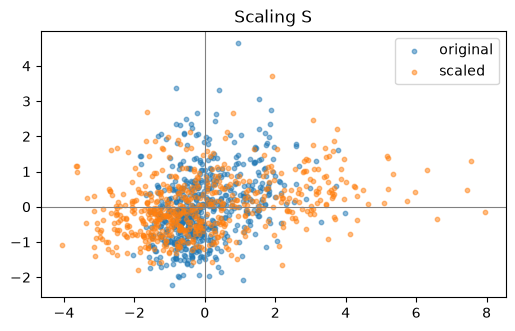

In [ ]:
# 1. x축은 2배, y축은 0.8배로 만드는 스케일링 행렬 `S = [[2, 0], [0, 0.8]]`를 정의합니다.
S = np.array([
    [2, 0],
    [0, 0.8]
])
S

# 2. `apply_T(S, X2)`를 계산해 변환된 좌표를 얻습니다. (이 실습의 모든 변환은 `apply_T`로 적용해 열벡터 관점을 통일합니다.)
print(X2.shape)
test = apply_T(S, X2)
print(test.shape)

# 3. 변환 전후의 각 축 표준편차를 비교합니다.
X2_std = X2.std(axis=0)
test_std = test.std(axis=0)
print(X2_std)
print(test_std)

# 4. `plot_pair()`로 변환 전후를 함께 그립니다.
plot_pair(X2, test, label_after='scaled', title='Scaling S')

# 5. 대각 원소가 각각 어떤 축을 담당하는지 한 문장으로 설명합니다.
# S의 대각 원소 2와 0.8은 각각 x축, y축의 크기를 담당

### 문제 1-2 : 반사와 투영 행렬 적용하기
1. x축 기준 반사 행렬 `F = [[1, 0], [0, -1]]`을 적용합니다.
2. 반사 전후에서 각 점의 원점까지 거리(L2 노름)가 유지되는지 확인합니다.
3. x축 위로 누르는 투영 행렬 `P = [[1, 0], [0, 0]]`을 적용합니다.
4. 투영 결과의 두 번째 축 값이 모두 0인지 확인합니다. 이어서 **같은 변환을 한 번 더 적용해 되돌릴 수 있는지**를 봅니다. `F @ F == I`인지, `P @ P == I`인지를 각각 확인하고, 다른 두 점 `[1, 2]`와 `[1, -5]`를 투영하면 어떻게 되는지도 함께 확인합니다.
5. 반사와 투영의 차이(정보 보존 여부)를 한 문장으로 설명합니다.

In [ ]:
# 1. x축 기준 반사 행렬 `F = [[1, 0], [0, -1]]`을 적용합니다.
F = np.array([
    [1, 0],
    [0, -1]
])
X_scaled2 = apply_T(F, X2)
# print(X2)
# print(X_scaled2)

# 2. 반사 전후에서 각 점의 원점까지 거리(L2 노름)가 유지되는지 확인합니다.
norm_X2 = []
norm_X_scaled2 = []
for i in range(len(X2)):
    # print(np.linalg.norm(X2[i]), end=" ,")
    # print(np.linalg.norm(X_scaled2[i]))
    norm_X2.append(np.linalg.norm(X2[i]))
    norm_X_scaled2.append(np.linalg.norm(X_scaled2[i]))
print(np.array_equal(norm_X2, norm_X_scaled2))
print(np.allclose(norm_X2, norm_X_scaled2))

# 3. x축 위로 누르는 투영 행렬 `P = [[1, 0], [0, 0]]`을 적용합니다.
P = np.array([
    [1, 0],
    [0, 0]
])
X_scaled3 = apply_T(P, X2)
print(X_scaled3)

# 4. 투영 결과의 두 번째 축 값이 모두 0인지 확인합니다. 이어서 **같은 변환을 한 번 더 적용해 되돌릴 수 있는지**를 봅니다. `F @ F == I`인지, `P @ P == I`인지를 각각 확인하고, 다른 두 점 `[1, 2]`와 `[1, -5]`를 투영하면 어떻게 되는지도 함께 확인합니다.
v1 = [1, 2]
v2 = [1, -5]
v1_scaled = apply_T(P, v1)
v2_scaled = apply_T(P, v2)
print(v1_scaled)
print(v2_scaled)

# 5. 반사와 투영의 차이(정보 보존 여부)를 한 문장으로 설명합니다.
# 가역, 비가역

True
True
[[ 1.09706398  0.        ]
 [ 1.82982061  0.        ]
 [ 1.57988811  0.        ]
 ...
 [ 0.70228425  0.        ]
 [ 1.83834103  0.        ]
 [-1.80840125  0.        ]]
[1 0]
[1 0]


## 필수 2 : 회전과 합성 변환, 그리고 순서 문제
시각화 담당자가 "데이터를 45도 돌린 다음 x축 방향으로 늘려 달라"는 요청과 "늘린 다음 돌려 달라"는 요청을 각각 받았습니다. 두 요청이 같은 결과를 낼 것 같지만, 행렬 곱은 순서를 바꾸면 결과가 달라집니다. 회전 행렬을 만들고 합성 순서에 따른 차이를 확인합니다.

### 문제 2-1 : 회전 행렬 만들고 적용하기
1. 45도(라디안 변환 필요)에 대한 회전 행렬 `R = [[cosθ, -sinθ], [sinθ, cosθ]]`을 만듭니다.
2. 검증용으로 벡터 `(1, 0)`에 회전 행렬을 적용해 결과가 `(0.71, 0.71)`에 가까운지 확인합니다.
3. `X2`에 회전을 적용하고 산점도로 확인합니다.
4. 회전 전후에서 원점까지의 거리가 유지되는지 확인합니다.
5. `RᵀR`을 계산해 단위행렬이 되는지 확인하고, 그 의미를 한 문장으로 설명합니다.

In [ ]:
# 1. 45도(라디안 변환 필요)에 대한 회전 행렬 `R = [[cosθ, -sinθ], [sinθ, cosθ]]`을 만듭니다.
theta = np.deg2rad(45)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
print(R)

# 2. 검증용으로 벡터 `(1, 0)`에 회전 행렬을 적용해 결과가 `(0.71, 0.71)`에 가까운지 확인합니다.
test_v = [1, 0]
print(apply_T(R, test_v))

# 3. `X2`에 회전을 적용하고 산점도로 확인합니다.
X2_rotated = apply_T(R, X2)
# plot_pair(X2, X2_rotated, "label_after=X2_rotated", title="tilte")

# 4. 회전 전후에서 원점까지의 거리가 유지되는지 확인합니다.
print(np.allclose(np.linalg.norm(X2, axis=1), np.linalg.norm(X2_rotated, axis=1)))

# 5. `RᵀR`을 계산해 단위행렬이 되는지 확인하고, 그 의미를 한 문장으로 설명합니다.
print(np.allclose(R.T @ R, np.eye(2)))
# 전치가 역행렬 -> 직교행렬. 즉 역행렬을 구하지 않고 전치만으로 되돌릴 수 있다.



[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
[0.70710678 0.70710678]
True
True


### 문제 2-2 : 합성 변환의 순서 비교하기
1. "스케일링 후 회전"에 해당하는 합성 행렬 `M1 = R @ S`를 만듭니다.
2. "회전 후 스케일링"에 해당하는 합성 행렬 `M2 = S @ R`를 만듭니다.
3. 두 행렬이 같은지 확인하고, 각각을 `X2`에 적용한 결과가 다른지 확인합니다.
4. 두 결과를 산점도로 비교합니다.
5. 변환 A를 먼저, B를 나중에 적용할 때 전체 변환이 `BA`가 되는 이유를 한 문장으로 설명합니다.

R @ S: [[ 1.41421356 -0.56568542]
 [ 1.41421356  0.56568542]], 
S @ R: [[ 1.41421356 -1.41421356]
 [ 0.56568542  0.56568542]], 
[[ True False]
 [False  True]]
False


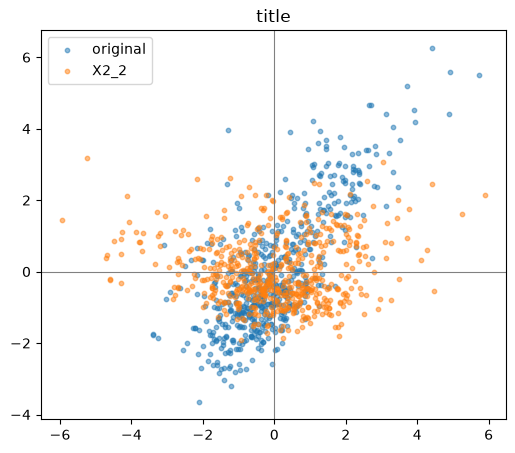

In [ ]:
# 1. "스케일링 후 회전"에 해당하는 합성 행렬 `M1 = R @ S`를 만듭니다.
M1 = R @ S

# 2. "회전 후 스케일링"에 해당하는 합성 행렬 `M2 = S @ R`를 만듭니다.
M2 = S @ R

# 3. 두 행렬이 같은지 확인하고, 각각을 `X2`에 적용한 결과가 다른지 확인합니다.
print(f"R @ S: {M1}, \nS @ R: {M2}, \n{np.isclose(M1, M2)}")
X2_1 = apply_T(M1, X2)
X2_2 = apply_T(M2, X2)
print(np.allclose(X2_1, X2_2))

# 4. 두 결과를 산점도로 비교합니다.
plot_pair(X2_1, X2_2, label_after="X2_2", title="title")

# 5. 변환 A를 먼저, B를 나중에 적용할 때 전체 변환이 `BA`가 되는 이유를 한 문장으로 설명합니다.


## 심화 1 : 이 변환은 정말 선형 변환일까?
보고서용으로 산점도 전체를 오른쪽 위로 옮겨 달라는 요청이 들어왔습니다. 이런 평행이동은 행렬 곱만으로는 표현할 수 없고, 실제로 선형 변환의 조건을 만족하지 않습니다. 선형 변환의 정의를 코드로 검증해 무엇이 선형이고 무엇이 아닌지 구분합니다.

### 문제 3-1 : 가산성·동차성으로 선형 변환 판별하기
1. 행렬 곱만 하는 변환 `T_linear(v) = apply_T(M1, v)`와, 평행이동을 더한 `T_affine(v) = apply_T(M1, v) + bias`를 정의합니다. (`bias = [3, -2]`)
2. 임의의 두 벡터 `u`, `v`와 스칼라 `c`를 정해, 두 변환에 대해 각각 다음을 확인합니다.
    - 가산성: `T(u + v) == T(u) + T(v)`
    - 동차성: `T(c·u) == c·T(u)`
    - 원점 보존: `T(0) == 0`
3. 두 변환의 결과를 표로 정리합니다.
4. `X2`에 두 변환을 적용해 산점도로 차이를 확인합니다.
5. 평행이동이 선형 변환이 아닌 이유와, 그럼에도 `XW + b`가 딥러닝에서 널리 쓰이는 이유를 2~3문장으로 작성합니다.

T(u + v) == T(u) + T(v)
T_linear: [ 2.54558441 17.25340546] == [ 2.54558441 17.25340546], True
T_affine: [ 5.54558441 15.25340546] == [ 8.54558441 13.25340546], False

T(cu) == cT(u)
T_linear: [ 0.56568542 16.40487732] == [ 0.56568542 16.40487732], True
T_affine: [ 3.56568542 14.40487732] == [ 6.56568542 12.40487732], False

T(0) == 0
T_linear: [0. 0.]
T_affine: [ 3. -2.]


c:\Users\limux\OneDrive\1. Projects\KANT Private LLM Infra Engineer 양성과정\기초수학실습\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\limux\OneDrive\1. Projects\KANT Private LLM Infra Engineer 양성과정\기초수학실습\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\limux\OneDrive\1. Projects\KANT Private LLM Infra Engineer 양성과정\기초수학실습\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\limux\OneDrive\1. Projects\KANT Private LLM Infra Engineer 양성과정\기초수학실습\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font

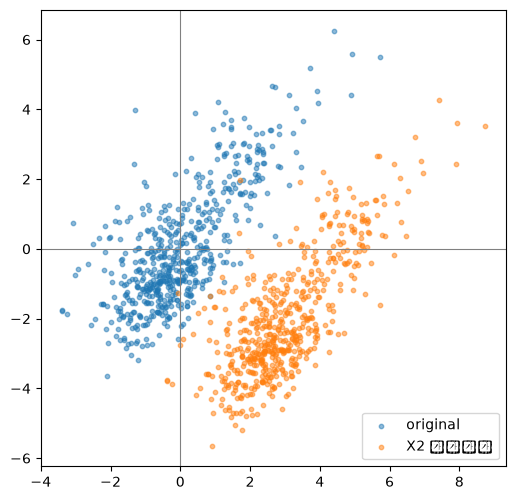

In [ ]:
# 1. 행렬 곱만 하는 변환 `T_linear(v) = apply_T(M1, v)`와, 평행이동을 더한 `T_affine(v) = apply_T(M1, v) + bias`를 정의합니다. (`bias = [3, -2]`)
def T_linear(v):
    # M1 = R @ S
    return v @ M1.T

def T_affine(v):
    # M1 = R @ S
    bias = np.array([3, -2])
    return (v @ M1.T) + bias

# 2. 임의의 두 벡터 `u`, `v`와 스칼라 `c`를 정해, 두 변환에 대해 각각 다음을 확인합니다.
#     - 가산성: `T(u + v) == T(u) + T(v)`
#     - 동차성: `T(c·u) == c·T(u)`
#     - 원점 보존: `T(0) == 0`
u = np.array([3, 7])
v = np.array([4, 6])
print("T(u + v) == T(u) + T(v)")
print(f"T_linear: {T_linear(u + v)} == {T_linear(u) + T_linear(v)}, {np.allclose(T_linear(u + v), T_linear(u) + T_linear(v))}")
print(f"T_affine: {T_affine(u + v)} == {T_affine(u) + T_affine(v)}, {np.allclose(T_affine(u + v), T_affine(u) + T_affine(v))}")


c = 2
print("\nT(cu) == cT(u)")
print(f"T_linear: {T_linear(c * u)} == {c * T_linear(u)}, {np.allclose(T_linear(c * u), c * T_linear(u))}")
print(f"T_affine: {T_affine(c * u)} == {c * T_affine(u)}, {np.allclose(T_affine(c * u), c * T_affine(u))}")


zero = np.array([0, 0])
print("\nT(0) == 0")
print(f"T_linear: {T_linear(zero)}")
print(f"T_affine: {T_affine(zero)}")

# 3. 두 변환의 결과를 표로 정리합니다.


# 4. `X2`에 두 변환을 적용해 산점도로 차이를 확인합니다.
X2_linear_scaled = T_linear(X2)
X2_affine_scaled = T_affine(X2)
# plot_pair(X2, X2_linear_scaled, label_after="X2 선형변환", title="")
plot_pair(X2_linear_scaled, X2_affine_scaled, label_after="X2 선형변환", title="")

# 5. 평행이동이 선형 변환이 아닌 이유와, 그럼에도 `XW + b`가 딥러닝에서 널리 쓰이는 이유를 2~3문장으로 작성합니다.
# 평행이동은 원점을 이동시키기 때문에 가산성과 동차성을 만족시키지 못한다.
# 